In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import sys
sys.path.append('..')  # Add Code directory to path

# Import utils package
from utils import (
    CholeskyBootstrapReturns,
    ControlMatrixPolicy,
    load_historical_returns,
    sample_without_replacement,
    SigmoidWealthPenalty,
    CRRAUtility,
    simulate_wealth_trajectory,
)

# Import new modular spending components
from utils.spending import *
from utils.allocation import *
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

torch.cuda.is_available()

True

In [2]:
N_ASSETS = 2
N_SIMULATIONS = 400_000
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Load historical returns using utils
try:
    yearly_returns, yearly_mean, yearly_cov = load_historical_returns(
        source="sallypy",
        bonds_ticker="BMK0017",
        stocks_ticker="BMK0188"
    )
except:
    # Fallback to CSV if sallypy not available
    print("Loading from CSV...")
    yearly_returns, yearly_mean, yearly_cov = load_historical_returns(
        source="csv",
        csv_path="../WIP/returns.csv"
    )

yearly_mean = yearly_mean.values
yearly_cov = yearly_cov.values
# add a constant inflation column to the returns dataframe

inflation_rate = 0.00  # Example constant inflation rate
yearly_returns['Inflation'] = inflation_rate
yearly_mean = np.append(yearly_mean, inflation_rate)
yearly_cov = np.pad(yearly_cov, ((0, 1), (0, 1)), 'constant', constant_values=0)

print(f"Mean annual returns:\n{yearly_mean}")
print(f"\nCovariance matrix:\n{yearly_cov}")
return_sampler = CholeskyBootstrapReturns(yearly_mean, yearly_cov, inflation_idx=2)

Mean annual returns:
[0.07692624 0.11243556 0.        ]

Covariance matrix:
[[0.00353543 0.00041295 0.        ]
 [0.00041295 0.04109719 0.        ]
 [0.         0.         0.        ]]


In [4]:
desired_spending = ConstantRealSpending(80_000)
consumption_floor = FixedRealFloor(init_floor=EXPENDITURE_GUIDELINES['no_frills_provincial_couple'])
income = NZSuper("couple")
income = NoIncome()
spending_policy = SpendingPolicy(
    spending=desired_spending,
    floor=consumption_floor,
    income=income
)
allocation_policy = ConstantAllocation(N_ASSETS, N_SIMULATIONS, DEVICE)

In [9]:
# clear GPU cache
torch.cuda.empty_cache()

In [10]:
INITIAL_WEALTH = 1_000_000
policy = torch.tensor([1.0], device=DEVICE, requires_grad=True)  
returns, cumulative_inflation = return_sampler.generate(N_SIMULATIONS, 30)  # Simulate 30 years of returns

returns = torch.tensor(returns, device=DEVICE)
cumulative_inflation = torch.tensor(cumulative_inflation, device=DEVICE)

In [22]:
# Setup optimizer
optimizer = torch.optim.Adam([policy], lr=0.0001, weight_decay=1e-5)

cost_history = []

for i in range(2000):
    # Zero gradients from previous iteration
    optimizer.zero_grad()

    wealth, consumption = simulate_wealth_trajectory(
        returns=returns,  # Simulate 30 years of returns
        cumulative_inflation=cumulative_inflation,
        allocation_policy=allocation_policy,
        spending_policy=spending_policy,
        initial_wealth=INITIAL_WEALTH,
        policy_settings=policy
    )
    cost = CRRAUtility(gamma=3.0, consumption_floor=EXPENDITURE_GUIDELINES['no_frills_provincial_couple'], normalize=True).evaluate(wealth, consumption)
    # cost = SigmoidWealthPenalty(steepness=1/EXPENDITURE_GUIDELINES['no_frills_provincial_couple']).evaluate(wealth, consumption)
    
    # Backward pass
    cost.backward()
    
    # Update weights
    optimizer.step()
    
    # Clamp policy to [0, 1]
    with torch.no_grad():
        policy.clamp_(0.0, 1.0)

    cost_history.append(cost.item())
    if (i + 1) % 20 == 0 or i == 0:
        print(f"Iteration {i + 1}/{2000}")
        print(f"  Cost: {cost.item():.6f}")
        print(f"  Mean consumption: ${consumption.mean().item():,.0f}")
        print(f"  Mean terminal wealth: ${wealth[:, -1].mean().item():,.0f}")
        print(f"  Bankruptcy rate: {(wealth[:, -1] == 0).sum().item() / N_SIMULATIONS:.2%}")
        print(f"  Learning rate: {optimizer.param_groups[0]['lr']:.6f}")
        print()


Iteration 1/2000
  Cost: -0.583814
  Mean consumption: $73,727
  Mean terminal wealth: $1,238,134
  Bankruptcy rate: 34.47%
  Learning rate: 0.000100

Iteration 20/2000
  Cost: -0.583824
  Mean consumption: $73,729
  Mean terminal wealth: $1,229,991
  Bankruptcy rate: 34.52%
  Learning rate: 0.000100

Iteration 40/2000
  Cost: -0.583831
  Mean consumption: $73,730
  Mean terminal wealth: $1,222,211
  Bankruptcy rate: 34.57%
  Learning rate: 0.000100

Iteration 60/2000
  Cost: -0.583835
  Mean consumption: $73,731
  Mean terminal wealth: $1,215,833
  Bankruptcy rate: 34.62%
  Learning rate: 0.000100

Iteration 80/2000
  Cost: -0.583838
  Mean consumption: $73,731
  Mean terminal wealth: $1,210,831
  Bankruptcy rate: 34.66%
  Learning rate: 0.000100

Iteration 100/2000
  Cost: -0.583840
  Mean consumption: $73,732
  Mean terminal wealth: $1,206,166
  Bankruptcy rate: 34.69%
  Learning rate: 0.000100

Iteration 120/2000
  Cost: -0.583841
  Mean consumption: $73,732
  Mean terminal wealth:

KeyboardInterrupt: 

In [ ]:
cost = CRRAUtility(gamma=1.2, consumption_floor=EXPENDITURE_GUIDELINES['no_frills_provincial_couple'], normalize=True).evaluate(wealth, consumption)
cost += SigmoidWealthPenalty(steepness=1/EXPENDITURE_GUIDELINES['no_frills_provincial_couple']).evaluate(wealth, consumption)

In [ ]:
cost.backward()

Text(0, 0.5, 'Cost')

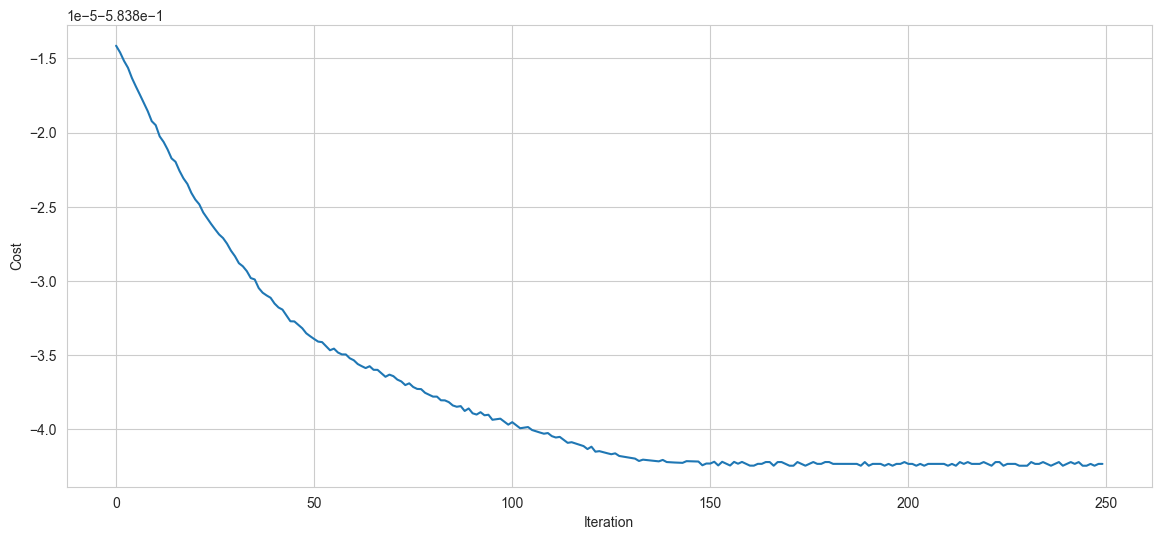

In [23]:
import matplotlib.pyplot as plt
plt.plot(cost_history)
plt.xlabel('Iteration') 
plt.ylabel('Cost')

In [19]:
policy

tensor([0.2681], device='cuda:0', requires_grad=True)

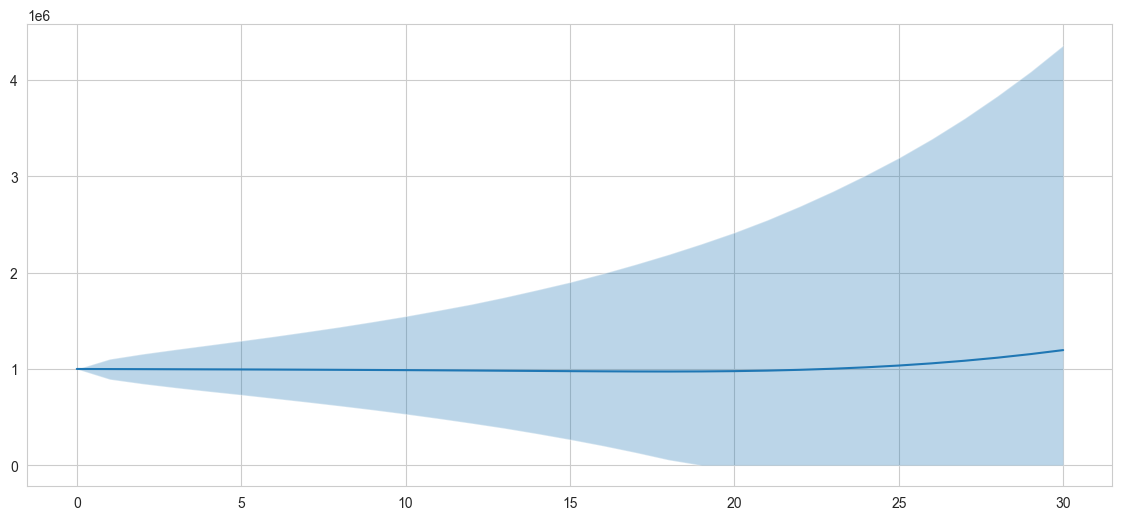

In [24]:
import matplotlib.pyplot as plt

wealth.detach().cpu().numpy()

avg_wealth = wealth.detach().mean(dim=0).cpu().numpy()
_95_percentile = torch.quantile(wealth.detach(), 0.95, dim=0).cpu().numpy()
_05_percentile = torch.quantile(wealth.detach(), 0.05, dim=0).cpu().numpy()
plt.plot(avg_wealth)
plt.fill_between(range(len(avg_wealth)), _05_percentile, _95_percentile, alpha=0.3) 

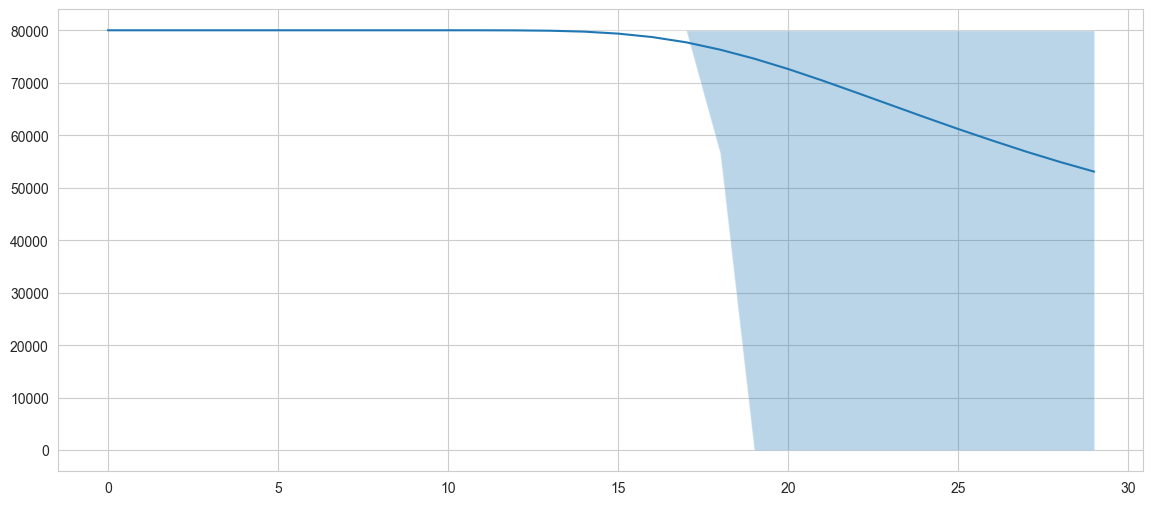

In [25]:
avg_consumption = consumption.detach().mean(dim=0).cpu().numpy()
_95_percentile_c = torch.quantile(consumption.detach(), 0.95, dim=0).cpu().numpy()
_05_percentile_c = torch.quantile(consumption.detach(), 0.05, dim=0).cpu().numpy()

plt.plot(avg_consumption)
plt.fill_between(range(len(avg_consumption)), _05_percentile_c, _95_percentile_c, alpha=0.3)

In [ ]:
_05_percentile_c

array([100000.        , 100000.        , 100000.        , 100000.        ,
       100000.        , 100000.        , 100000.        , 100000.        ,
       100000.        , 100000.        , 100000.        , 100000.        ,
       100000.        , 100000.        , 100000.        , 100000.        ,
       100000.        , 100000.        , 100000.        , 100000.        ,
        49082.47009785,  46055.        ,  46055.        ,  46055.        ,
        46055.        ,  46055.        ,  46055.        ,  46055.        ,
        46055.        ,  46055.        ])